# Venn diagrams for SNPs and gRNAs
Python `venn` package

input: `merged_snp_gene_master_updated.xlsx`  
Cell-line: `Het_in_KOLF2`, `Het_in_WTB`, `Het_in_WTC`, `Het_in_WTD`, `Het_in_p47`

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from venn import venn


In [3]:

merged_snp_gene_master = Path("merged_snp_gene_master_updated.xlsx")
snp_gene_master = pd.read_excel(merged_snp_gene_master, sheet_name="Editor_With_Gene_Info")

cell_line_cols = {
    "KOLF2": "Het_in_KOLF2",
    "WTB": "Het_in_WTB",
    "WTC": "Het_in_WTC",
    "WTD": "Het_in_WTD",
    "p47": "Het_in_p47",
}

for col in cell_line_cols.values():
    snp_gene_master[col] = pd.to_numeric(snp_gene_master[col], errors="coerce").fillna(0).astype(int)

snp_gene_master.head()

,gene,snp,af,distance_to_exon_boundary,avg_dist,editor,type,chrom,start,end,...,GeneInfo_Cardiac_WTC_LooseQC_Detection_Rate_Mean_%,GeneInfo_Cardiac_WTC_LooseQC_Mean_Expr_All_Mean,GeneInfo_Cardiac_WTC_LooseQC_Mean_Expr_Detected_Mean,GeneInfo_Cardiac_WTC_LooseQC_Aggregated_CPM_Mean,GeneInfo_Cardiac_WTC_LooseQC_Cell_Types,GeneInfo_Neuron_LooseQC_Detection_Rate_Mean_%,GeneInfo_Neuron_LooseQC_Mean_Expr_All_Mean,GeneInfo_Neuron_LooseQC_Mean_Expr_Detected_Mean,GeneInfo_Neuron_LooseQC_Aggregated_CPM_Mean,GeneInfo_Neuron_LooseQC_Cell_Types
0,CFH,196690107,0.73,{44},44.0,ABE,acceptor,chr1,196690089,196690108,...,0.3167,0.0017,0.5548,0.3087,WTC Day 13 cardiomyocytes; WTC Day 15 cardiomy...,5.17,0.0397,0.7684,7.9260,"iPSC-Neuron, Day 21"
1,CFH,196690107,0.73,{44},44.0,ABE,acceptor,chr1,196690089,196690108,...,0.3167,0.0017,0.5548,0.3087,WTC Day 13 cardiomyocytes; WTC Day 15 cardiomy...,5.17,0.0397,0.7684,7.9260,"iPSC-Neuron, Day 21"
2,ITGA2B,44372421,0.40,{2},2.0,ABE,acceptor,chr17,44372405,44372424,...,0.9267,0.0040,0.4241,0.5467,WTC Day 13 cardiomyocytes; WTC Day 15 cardiomy...,1.50,0.0124,0.8265,2.0858,"iPSC-Neuron, Day 21"
3,ITGA2B,44372421,0.40,{2},2.0,ABE,acceptor,chr17,44372405,44372424,...,0.9267,0.0040,0.4241,0.5467,WTC Day 13 cardiomyocytes; WTC Day 15 cardiomy...,1.50,0.0124,0.8265,2.0858,"iPSC-Neuron, Day 21"
4,ITGA2B,44372421,0.40,{2},2.0,ABE,acceptor,chr17,44372406,44372425,...,0.9267,0.0040,0.4241,0.5467,WTC Day 13 cardiomyocytes; WTC Day 15 cardiomy...,1.50,0.0124,0.8265,2.0858,"iPSC-Neuron, Day 21"


In [4]:
snp_gene_master["SNP_ID"] = (
    snp_gene_master["gene"].astype(str)+ "|"
    + snp_gene_master["chrom"].astype(str)+ "|"
    + snp_gene_master["snp"].astype(str)
)

snp_sets = {}
grna_sets = {}

for cell_line, col in cell_line_cols.items():
    snp_sets[cell_line] = set(snp_gene_master.loc[snp_gene_master[col] == 1, "SNP_ID"].dropna())
    grna_sets[cell_line] = set(snp_gene_master.loc[snp_gene_master[col] == 1, "gRNA"].dropna())

pd.DataFrame({
    "Cell_Line": list(cell_line_cols),
    "SNPs": [len(snp_sets[x]) for x in cell_line_cols],
    "gRNAs": [len(grna_sets[x]) for x in cell_line_cols],
})

,Cell_Line,SNPs,gRNAs
0,KOLF2,193,917
1,WTB,182,771
2,WTC,199,837
3,WTD,189,892
4,p47,207,959


SNP Venn diagram

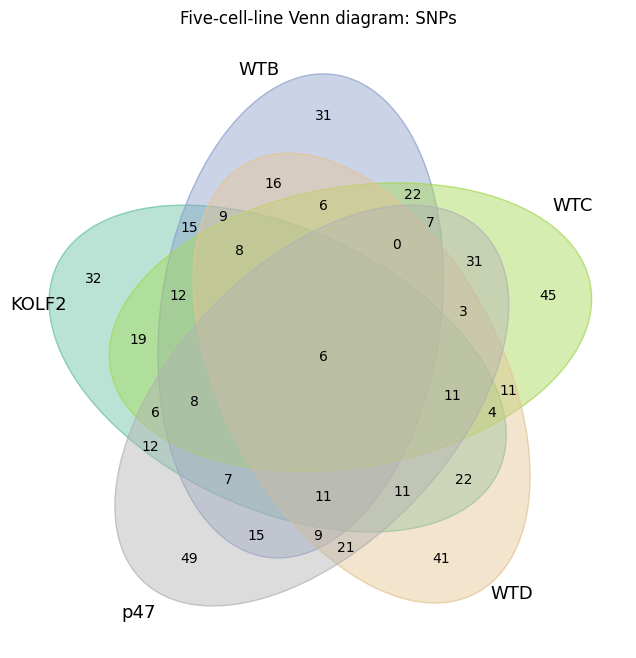

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))
venn(snp_sets, fmt="{size}", cmap="Set2", alpha=0.45, fontsize=10, legend_loc=None, ax=ax)

# put the set names next to the ellipses
ax.text(0.0, 0.55, "KOLF2", transform=ax.transAxes, fontsize=13)
ax.text(0.37, 0.93, "WTB", transform=ax.transAxes, fontsize=13)
ax.text(0.88, 0.71, "WTC", transform=ax.transAxes, fontsize=13)
ax.text(0.78, 0.08, "WTD", transform=ax.transAxes, fontsize=13)
ax.text(0.18, 0.05, "p47", transform=ax.transAxes, fontsize=13)

plt.title("Five-cell-line Venn diagram: SNPs")
#plt.savefig("five_set_snp_venn_normal.png", dpi=240, bbox_inches="tight")
plt.show()

gRNA Venn diagram

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
venn(grna_sets, fmt="{size}", cmap="Set2", alpha=0.45, fontsize=10, legend_loc=None, ax=ax)

# Put the set names next to the ellipses instead of using a legend.
ax.text(0.02, 0.55, "KOLF2", transform=ax.transAxes, fontsize=13)
ax.text(0.37, 0.98, "WTB", transform=ax.transAxes, fontsize=13)
ax.text(0.88, 0.78, "WTC", transform=ax.transAxes, fontsize=13)
ax.text(0.78, 0.08, "WTD", transform=ax.transAxes, fontsize=13)
ax.text(0.18, 0.10, "p47", transform=ax.transAxes, fontsize=13)

plt.title("Five-cell-line Venn diagram: gRNAs")
#plt.savefig("five_set_grna_venn_normal.png", dpi=240, bbox_inches="tight")
plt.show()